## 준비

In [34]:
import os
import time
import copy
import glob
import cv2
import shutil
import zipfile
import random

import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision.models import resnet18, ResNet18_Weights

import matplotlib.pyplot as plt

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 데이터 다운로드 (한 번 했으면 생략)

In [14]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"likeabies","key":"b92c2c89fb2fd3a9e1b9297fc1048a51"}'}

In [15]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Dogs vs Cats 데이터 다운로드
!kaggle competitions download -c dogs-vs-cats

dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [23]:
base_dir = '/content/drive/MyDrive/boaz/mm_pytorch/data'
target_dir = os.path.join(base_dir, 'train_raw')

# 압축 해제 함수
def unzip_to_target(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
        print(f"✅ 압축 해제 완료: {zip_path}")

# train.zip 압축 해제
unzip_to_target(os.path.join(base_dir, 'train.zip'), target_dir)

# test1.zip 압축 해제 (필요한 경우에만 주석 제거)
# unzip_to_target(os.path.join(base_dir, 'test1.zip'), target_dir)

✅ 압축 해제 완료: /content/drive/MyDrive/boaz/mm_pytorch/data/train.zip


In [29]:
import os
import shutil
import random

src_dir = '/content/drive/MyDrive/boaz/mm_pytorch/data/train_raw/train'

# 대상 폴더
dst_dir_cat = '/content/drive/MyDrive/boaz/mm_pytorch/data/train/cat'
dst_dir_dog = '/content/drive/MyDrive/boaz/mm_pytorch/data/train/dog'
test_dir    = '/content/drive/MyDrive/boaz/mm_pytorch/data/test'

# 폴더 생성
os.makedirs(dst_dir_cat, exist_ok=True)
os.makedirs(dst_dir_dog, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# 기존 폴더 초기화 함수
def clear_folder(folder):
    for f in os.listdir(folder):
        file_path = os.path.join(folder, f)
        if os.path.isfile(file_path):
            os.remove(file_path)

# 기존 train, test 폴더 이미지 삭제
clear_folder(dst_dir_cat)
clear_folder(dst_dir_dog)
clear_folder(test_dir)

# 전체 파일 목록에서 cat, dog 따로 분리
all_files  = os.listdir(src_dir)
cat_files  = [f for f in all_files if f.startswith('cat') and f.endswith('.jpg')]
dog_files  = [f for f in all_files if f.startswith('dog') and f.endswith('.jpg')]

# 랜덤으로 250개씩 샘플링해서 이동
cat_sample = random.sample(cat_files, 250)
dog_sample = random.sample(dog_files, 250)

def move_files(file_list, dst_folder):
    for fname in file_list:
        src_path = os.path.join(src_dir, fname)
        dst_path = os.path.join(dst_folder, fname)
        shutil.move(src_path, dst_path)

move_files(cat_sample, dst_dir_cat)
move_files(dog_sample, dst_dir_dog)

# 나머지 중에서 25개씩 테스트용으로 복사
remaining_cat = list(set(cat_files) - set(cat_sample))
remaining_dog = list(set(dog_files) - set(dog_sample))

cat_test = random.sample(remaining_cat, 25)
dog_test = random.sample(remaining_dog, 25)

def copy_files(file_list, dst_folder):
    for fname in file_list:
        src_path = os.path.join(src_dir, fname)
        dst_path = os.path.join(dst_folder, fname)
        shutil.copy2(src_path, dst_path)

copy_files(cat_test, test_dir)
copy_files(dog_test, test_dir)

print(f"총 테스트 이미지 수: {len(cat_test) + len(dog_test)}장 (cat: {len(cat_test)}, dog: {len(dog_test)})")


총 테스트 이미지 수: 50장 (cat: 25, dog: 25)


In [30]:
cat_dir = '/content/drive/MyDrive/boaz/mm_pytorch/data/train/cat'
dog_dir = '/content/drive/MyDrive/boaz/mm_pytorch/data/train/dog'
test_dir = '/content/drive/MyDrive/boaz/mm_pytorch/data/test'

print('cat 폴더 파일 수:', len(os.listdir(cat_dir)))
print('dog 폴더 파일 수:', len(os.listdir(dog_dir)))
print('test 폴더 파일 수:', len(os.listdir(test_dir)))

cat 폴더 파일 수: 250
dog 폴더 파일 수: 250
test 폴더 파일 수: 50


### 데이터 전처리

In [31]:
data_path = '/content/drive/MyDrive/boaz/mm_pytorch/data/train'

transform = transforms.Compose(
    [
      transforms.Resize((256, 256)),        # 이미지를 쓰고자 하는 모델에 맞게 resize
      transforms.RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.9, 1.1)),
      # 이미지를 랜덤하게 자르고 224 크기로 재설정
      # default : scale=(0.08, 1.0), ratio=(3/4, 4/3)
      transforms.RandomHorizontalFlip(),
      transforms.ToTensor()
])

train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

In [32]:
# 데이터 구조 확인 (레이블)
print(train_dataset.classes)
print(train_dataset.class_to_idx)

# 데이터 구조 확인 (데이터)
print(len(train_dataset))
image, label = train_dataset[0]
print(image.shape)

['cat', 'dog']
{'cat': 0, 'dog': 1}
500
torch.Size([3, 224, 224])


### RandomResizedCrop 시각적 확인 (생략 가능)

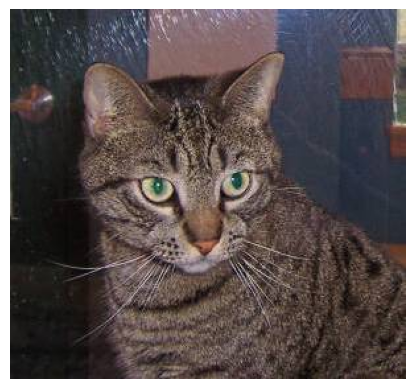

In [9]:
from PIL import Image
example_image = Image.open('/content/drive/MyDrive/boaz/mm_pytorch/data/train/cat/cat.1.jpg')
plt.imshow(example_image)
plt.axis('off')
plt.show()

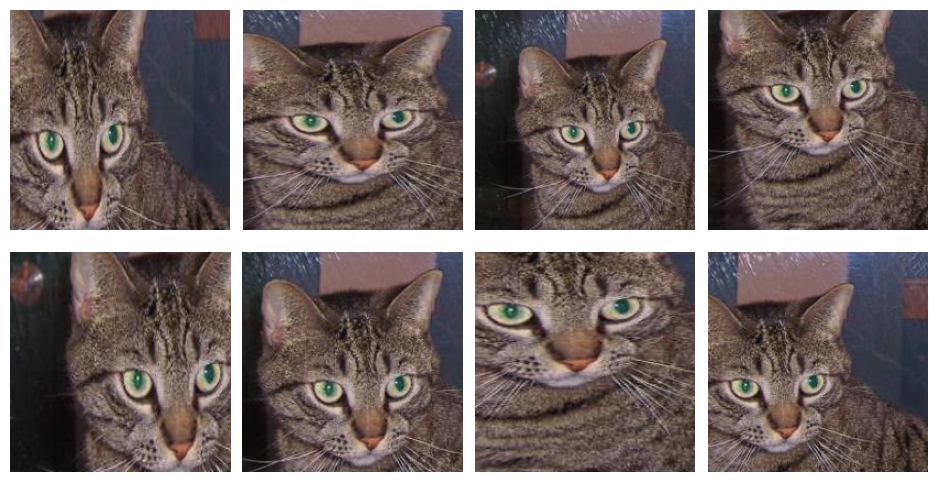

In [10]:
# 시각화 함수
def show_images(imgs, num_rows, num_cols, scale=2):
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    for i in range(num_rows):
        for j in range(num_cols):
            img = imgs[i * num_cols + j]
            if isinstance(img, torch.Tensor):
                img = transforms.ToPILImage()(img)
            axes[i][j].imshow(img)
            axes[i][j].axis('off')

    plt.subplots_adjust(hspace=0.1, wspace=0)
    return axes

# 증강 적용 함수
def apply(img, aug, num_rows=2, num_cols=4, scale=3):
    Y = [aug(img) for _ in range(num_rows * num_cols)]
    show_images(Y, num_rows, num_cols, scale)

# RandomResizedCrop 정의
shape_aug = transforms.Compose([
    transforms.RandomResizedCrop(size=(200, 200), scale=(0.1, 1), ratio=(0.5, 2)),
    transforms.ToTensor()  # PyTorch 텐서로 변환
])

# 적용
apply(example_image, shape_aug)

### 학습에 사용될 이미지 시각적 확인

In [13]:
samples, labels = next(iter(train_loader))
print(samples.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


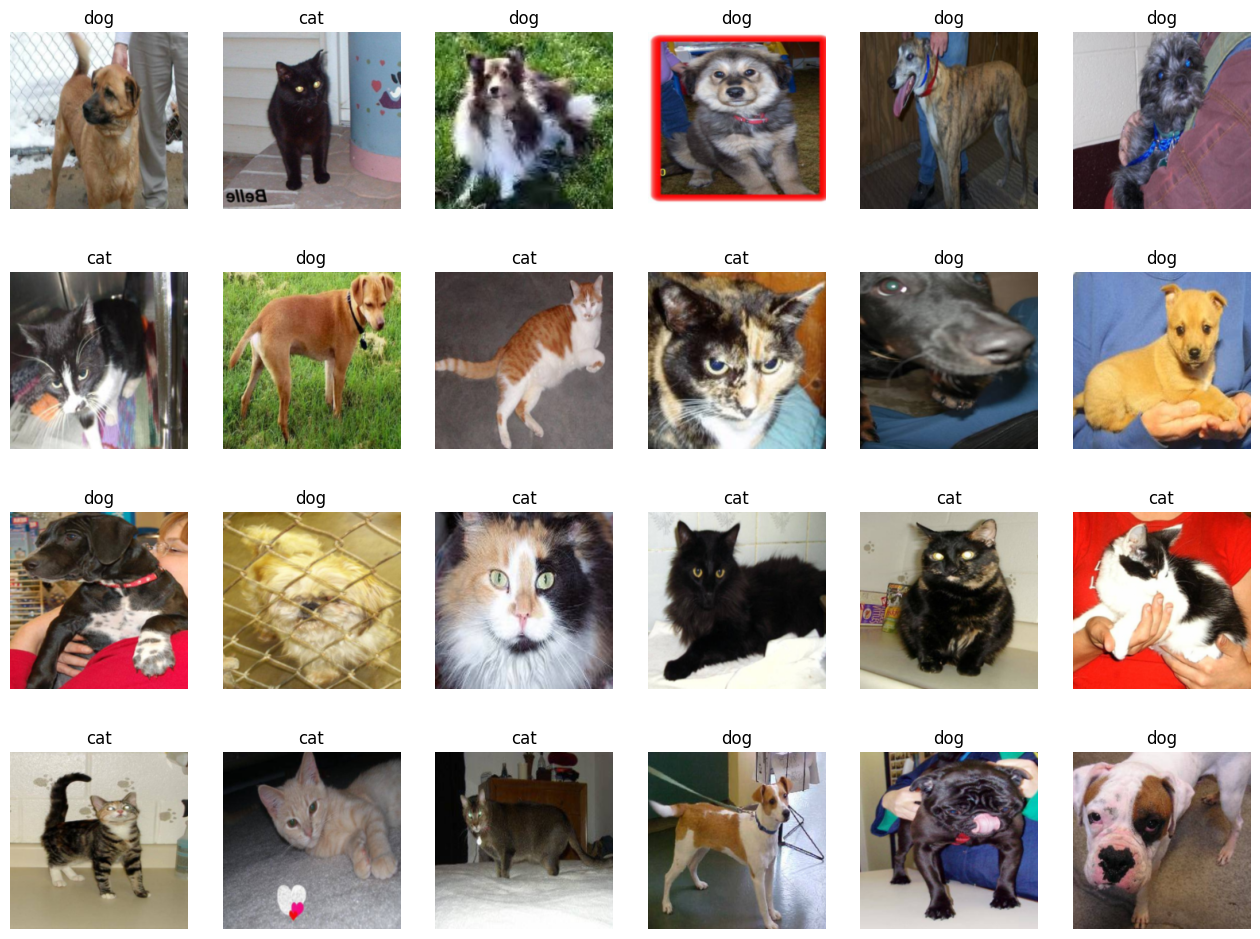

In [15]:
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize = (16,24))
for i in range(24):
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()])
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
  plt.subplots_adjust(bottom = 0.2, top = 0.6, hspace = 0)

## 전이학습

In [35]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)  # wieghts=Resnet18_Weights.DEFAULT -> 사전학습된 가중치를 사용

In [36]:
def set_parameter_requires_grad(model, feature_extracting = True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False

set_parameter_requires_grad(model)

In [37]:
for name, param in model.named_parameters():  #사전 학습된 가중치 값 확인
  if param.requires_grad:
    print(name, param.data)

In [38]:
model.fc = torch.nn.Linear(512,2)
for param in model.fc.parameters():
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [39]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [40]:
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time()
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs):
    print('Epoch {}/{}'.format(epoch, num_epochs - 1))
    print('-' * 10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders:        # 배치별 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()*inputs.size(0)           #criterion은 배치별 평균 손실을 구해주기 때문에 다시 곱해줌
      running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(dataloaders.dataset)
    epoch_acc = running_corrects.double() / len(dataloaders.dataset)  # .double -> 텐서를 64비트 부동소수형으로 변경

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())

    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join(data_path, '{:02d}.pth'.format(epoch)))  #pth : 확장자 명
    print()

  time_elapsed = time.time() - since
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history

In [41]:
params_to_update = []
for name, param in model.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param)
    print('\t',name)

optimizer = optim.Adam(params_to_update)      #학습할 파라미터를 optimizer에 전달 (필요 없어보임)

	 fc.weight
	 fc.bias


In [42]:
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(model, train_loader, criterion, optimizer, device)

Epoch 0/12
----------
Loss: 0.4942 Acc: 0.7660

Epoch 1/12
----------
Loss: 0.2654 Acc: 0.9260

Epoch 2/12
----------
Loss: 0.2089 Acc: 0.9400

Epoch 3/12
----------
Loss: 0.1520 Acc: 0.9520

Epoch 4/12
----------
Loss: 0.1431 Acc: 0.9500

Epoch 5/12
----------
Loss: 0.1277 Acc: 0.9620

Epoch 6/12
----------
Loss: 0.1107 Acc: 0.9680

Epoch 7/12
----------
Loss: 0.1033 Acc: 0.9700

Epoch 8/12
----------
Loss: 0.1008 Acc: 0.9660

Epoch 9/12
----------
Loss: 0.0957 Acc: 0.9800

Epoch 10/12
----------
Loss: 0.0975 Acc: 0.9780

Epoch 11/12
----------
Loss: 0.0814 Acc: 0.9780

Epoch 12/12
----------
Loss: 0.0636 Acc: 0.9880

Training complete in 2m 52s
Best Acc: 0.988000


In [61]:
# 테스트 이미지 로드

test_path = '/content/drive/MyDrive/boaz/mm_pytorch/data/test'

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=1
)

print(len(test_dataset))

50


In [63]:
def eval_model(model, dataloaders, device):
  since =time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('/content/drive/MyDrive/boaz/mm_pytorch/data/train/' + '*.pth')
  saved_models.sort()
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))     # torch.load가 .path를 OrderedDict 형태로 전환 / load_state_dict가 파라미터를 교체
    model.eval()                                      # 학습 모드에서 평가 모드로 전환
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders:
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad():
        outputs = model(inputs)

      _, preds = torch.max(outputs.data, dim = 1)         # 1 : 행 기준
      preds[preds >= 0.5] = 1
      preds[preds < 0.5] = 0
      running_corrects += torch.sum(preds == labels.data)

    epoch_acc = running_corrects.double() / len(dataloaders.dataset)
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc
    acc_history.append(epoch_acc.item())
    print()

  time_elpased = time.time() - since
  print('Validation complet in {:.0f}m {:.0f}s'.format(time_elpased // 60, time_elpased % 60))  # 분 계산(몫), 초 계산(나머지)
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history

In [64]:
val_acc_hist = eval_model(model, test_loader, device)

saved_model ['/content/drive/MyDrive/boaz/mm_pytorch/data/train/00.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/01.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/02.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/03.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/04.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/05.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/06.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/07.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/08.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/09.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/10.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/11.pth', '/content/drive/MyDrive/boaz/mm_pytorch/data/train/12.pth']
Loading model /content/drive/MyDrive/boaz/mm_pytorch/data/train/00.pth
Acc: 0.9000

Loading model /content/drive/MyDrive/boaz/mm_pytorch/data/train/01.pth
Acc: 0.9200

Loading model /content/drive/MyDrive/bo

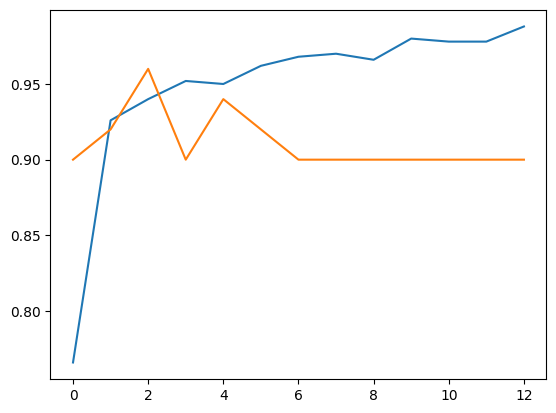

In [65]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)

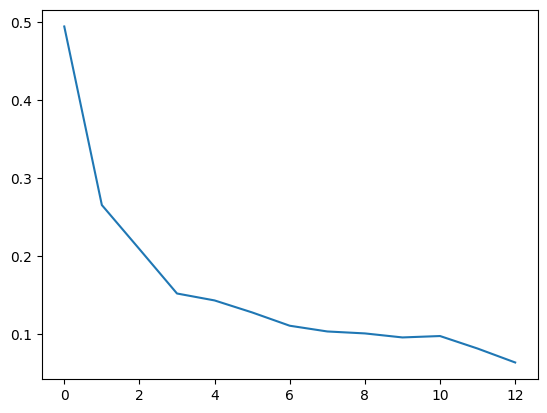

In [66]:
plt.plot(train_loss_hist)
plt.show()

In [71]:
def im_convert(tensor):
  image = tensor.clone().detach().cpu().numpy()
  image = image.transpose(1,2,0)
  # image = image*(np.array((0.5,0.5,0.5))) + np.arrary((0.5,0.5.0.5)))  # 역정규화 과정이라는데, 나는 정규화 한 적이 없어요
  image = image.clip(0,1)
  return image

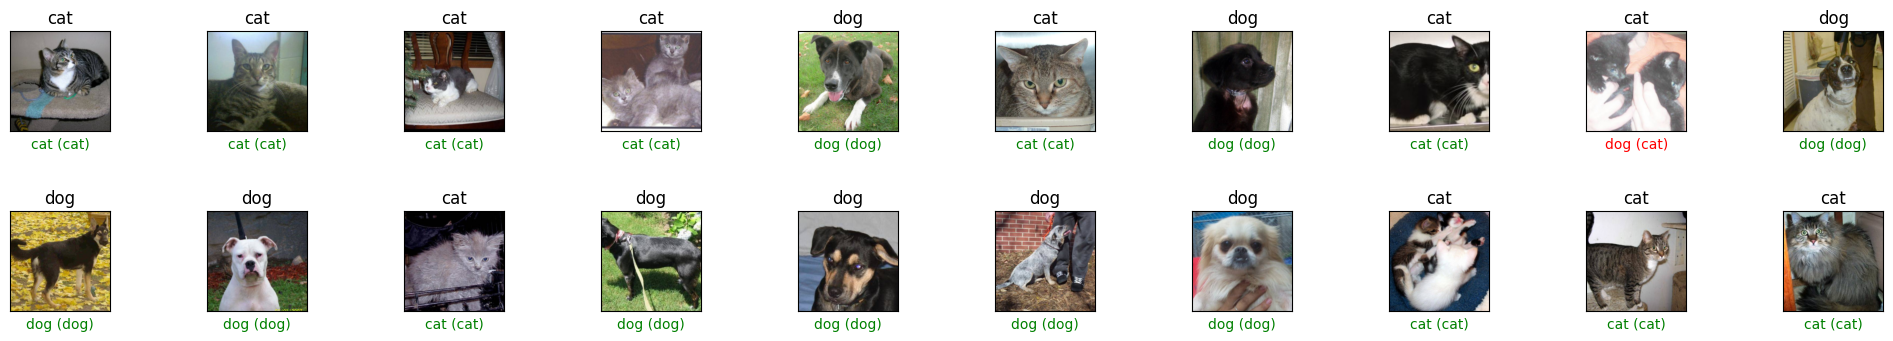

In [73]:
# 클래스 레이블 정의
classes = {0: 'cat', 1: 'dog'}

# 데이터 가져오기
dataiter = iter(test_loader)
images, labels = next(dataiter)
images = images.to(device)
labels = labels.to(device)

# 모델 추론
output = model(images)
_, preds = torch.max(output, 1)

# 시각화
fig = plt.figure(figsize=(25, 4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx + 1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))  # 변환 함수 적용
    ax.set_title(classes[labels[idx].item()])
    ax.set_xlabel(
        "{} ({})".format(
            str(classes[preds[idx].item()]),
            str(classes[labels[idx].item()])
        ),
        color="green" if preds[idx] == labels[idx] else "red"
    )

plt.subplots_adjust(bottom=0.15, top=0.85, hspace=0.8)
plt.show()